In [2]:
## Imports and prereqs
import numpy as np
import matplotlib.pyplot as plt
import os
import scipy
import yaml

foldname = 'Day4'
filename = 'AngularDependence.csv'

if "data" not in os.getcwd():
    path = os.path.join(os.path.dirname(os.getcwd()), 'data', foldname)
    os.chdir(path)


In [3]:
## Load the data file

data = np.loadtxt(filename, delimiter=',', dtype=float, skiprows=1)
head = np.loadtxt(filename, delimiter=',', dtype=str  , max_rows=1)

angles = data[:,0]
triple = data[:,1]
double = data[:,2]

#angles = [23, 23, 23, 24, 24, 25]
#triple = [10, 11, 11, 76, 72, 30]
#double = [70, 71, 71, 16, 12, 40]

# Get the different possible angles
anglesList = []

for angle in angles:
    if angle in anglesList:
        pass
    else:
        anglesList.append(angle)

# Sort each of the given values in their independent list
tripleList = [np.array([]) for i in range(len(anglesList))]
doubleList = [np.array([]) for i in range(len(anglesList))]

for i in range(len(angles)):
    aNam = anglesList.index(angles[i])
    tripleList[aNam] = np.append(tripleList[aNam], triple[i])
    doubleList[aNam] = np.append(doubleList[aNam], double[i])

# Print the lists
print(anglesList)
print(tripleList)
print(doubleList)

[0.0, 11.0, 18.0, 30.0, 41.0, 50.0, 61.0, 70.0, 80.0, 89.0, 7.0, 15.0, 25.0, 36.0, 47.0, 55.0, 66.0, 76.0, 85.0]
[array([48., 63., 45., 58., 46., 48., 59., 42., 69., 63.]), array([55., 61., 50., 48., 60., 61., 71., 49., 48., 50.]), array([47., 52., 50., 44., 34., 54., 51., 65., 52., 54.]), array([38., 39., 41., 42., 53., 40., 33., 41., 50., 39.]), array([40., 36., 18., 24., 24., 45., 39., 27., 27., 35.]), array([18., 24., 33., 26., 25., 22., 28., 24., 24., 20.]), array([13., 12., 19., 16., 19., 14., 19., 16., 21., 15.]), array([12.,  7., 11.,  8.,  6.,  8.,  7.,  6.,  9.,  8.]), array([6., 4., 5., 7., 9., 3., 5., 6., 3., 6.]), array([3., 3., 4., 7., 6., 2., 4., 3., 2., 6.]), array([56., 65., 60., 49., 61., 67., 51., 52., 52., 70.]), array([54., 56., 40., 53., 49., 45., 46., 50., 46., 68.]), array([50., 47., 39., 49., 47., 36., 49., 42., 55., 62.]), array([39., 33., 46., 37., 46., 35., 38., 34., 50., 53.]), array([22., 33., 26., 26., 33., 27., 29., 28., 28., 32.]), array([17., 20., 16.,

In [4]:
## Process the data

# Get the mean of everything
buf = np.array([np.array([0,0]) for i in range(len(tripleList))])
for i in range(len(tripleList)):
    buf[i] = np.array([np.mean(tripleList[i]), np.std(tripleList[i])])
tripleList = buf

buf = np.array([np.array([0,0]) for i in range(len(doubleList))])
for i in range(len(doubleList)):
    buf[i] = np.array([np.mean(doubleList[i]), np.std(doubleList[i])])
doubleList = buf


[0.0, 11.0, 18.0, 30.0, 41.0, 50.0, 61.0, 70.0, 80.0, 89.0, 7.0, 15.0, 25.0, 36.0, 47.0, 55.0, 66.0, 76.0, 85.0]
[[54  8]
 [55  7]
 [50  7]
 [41  5]
 [31  8]
 [24  3]
 [16  2]
 [ 8  1]
 [ 5  1]
 [ 4  1]
 [58  7]
 [50  7]
 [47  7]
 [41  6]
 [28  3]
 [18  3]
 [12  2]
 [ 7  3]
 [ 5  1]]
[[61  6]
 [53  6]
 [49  5]
 [42  5]
 [32  3]
 [24  3]
 [15  3]
 [12  2]
 [ 6  1]
 [ 5  2]
 [54  9]
 [54  7]
 [49  6]
 [39  6]
 [25  7]
 [18  2]
 [11  3]
 [ 6  2]
 [ 4  1]]


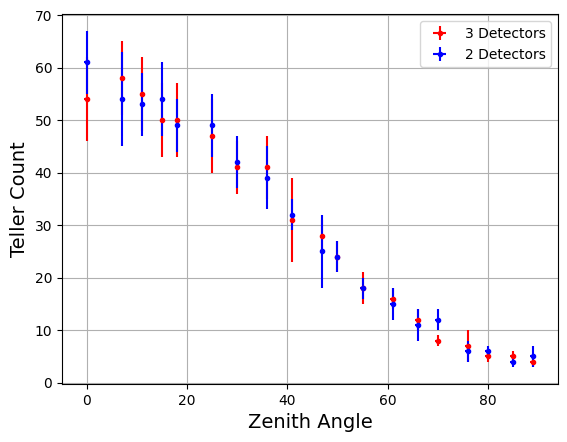

In [5]:
## Show the processed data

# Print it again
print(anglesList)
print(tripleList)
print(doubleList)

xErr = 0.5

# Plot it too
plt.errorbar(anglesList, tripleList[:,0], xerr = xErr, yerr = tripleList[:,1], fmt = '.',color = 'red' , label = "3 Detectors")
plt.errorbar(anglesList, doubleList[:,0], xerr = xErr, yerr = doubleList[:,1], fmt = '.',color = 'blue', label = "2 Detectors")
plt.legend()
plt.grid()

plt.xlabel('Zenith Angle', fontdict={'size' : 14})
plt.ylabel('Teller Count', fontdict={'size' : 14})

plt.show()

In [6]:
## Fit the data
import odrpack

# Cos^n fitting def
def fitting_funct(xVal, params: np.ndarray):
    '''Fitting function for the given datapoints'''
    return params[0]*np.power((np.cos(xVal*(np.pi/180))),params[1]) + params[2] 

# TRIPLE
print("Triple:")
popt, _ = scipy.optimize.curve_fit(lambda x,a,b,c: fitting_funct(x,[a,b,c]), anglesList, tripleList[:,0], sigma=tripleList[:,1])

output = odrpack.odr_fit(fitting_funct, anglesList, tripleList[:,0], popt, 
                          weight_x=1/(xErr)**2, weight_y=1/tripleList[:,1]**2,
                          bounds = [0.8*popt,1.15*popt])

print(output.beta)
print(f'Lower bounds: {0.8*popt}')
print(f'Upper bounds: {1.15*popt}')

for i in range(len(output.beta)):
    print(f"Statistical error on parameter {i}: {round(np.sqrt(output.cov_beta[i][i])/(abs(output.beta[i]))*100, 2)}%")

output3 = output

# DOUBLE
print("Double:")
popt, _ = scipy.optimize.curve_fit(lambda x,a,b,c: fitting_funct(x,[a,b,c]), anglesList, doubleList[:,0], sigma=doubleList[:,1])

output = odrpack.odr_fit(fitting_funct, anglesList, doubleList[:,0], popt, 
                          weight_x=1/(xErr)**2, weight_y=1/doubleList[:,1]**2,
                          bounds = [0.8*popt,1.15*popt])

print(output.beta)
print(f'Lower bounds: {0.8*popt}')
print(f'Upper bounds: {1.15*popt}')

for i in range(len(output.beta)):
    print(f"Statistical error on parameter {i}: {round(np.sqrt(output.cov_beta[i][i])/(abs(output.beta[i]))*100, 2)}%")

output2 = output


Triple:
[52.70922312  2.23392295  4.14318174]
Lower bounds: [42.19045938  1.78954369  3.31298994]
Upper bounds: [60.64878536  2.57246906  4.76242304]
Statistical error on parameter 0: 5.46%
Statistical error on parameter 1: 8.14%
Statistical error on parameter 2: 15.36%
Double:
[52.23512143  2.23907062  4.50364336]
Lower bounds: [41.78294898  1.79389949  3.61053441]
Upper bounds: [60.06298915  2.57873052  5.19014321]
Statistical error on parameter 0: 5.04%
Statistical error on parameter 1: 9.45%
Statistical error on parameter 2: 16.7%


C:\Users\Dumitru Andrei\AppData\Local\Temp\ipykernel_18456\874236068.py:7: RuntimeWarning: invalid value encountered in power
  return params[0]*np.power((np.cos(xVal*(np.pi/180))),params[1]) + params[2]


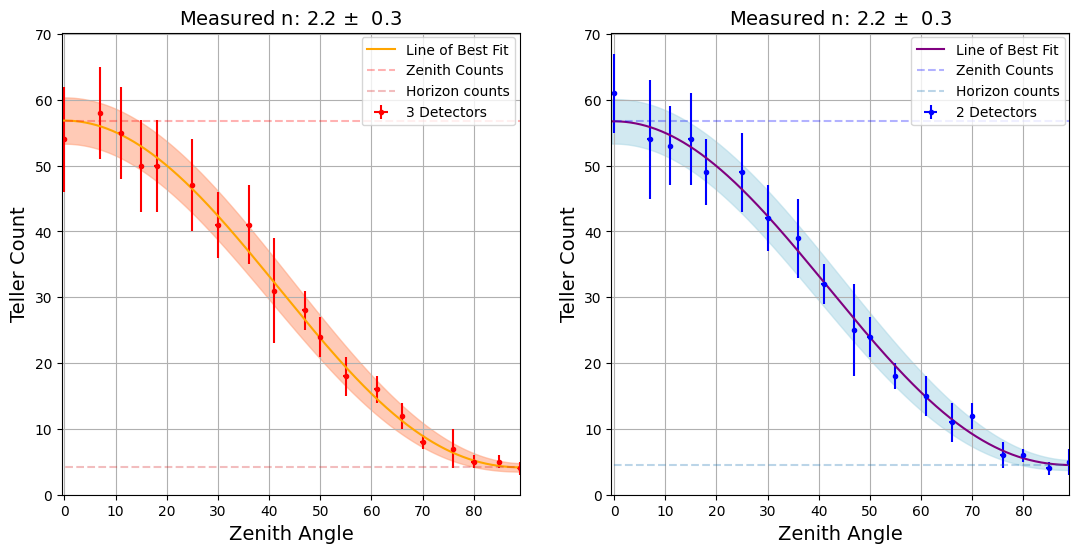

In [7]:
## Plot the data and fit

def errorRound(val, ndigits):
    return round(1 + np.sqrt(val)*10**ndigits)/(10**ndigits)

# Make figure
fig, ax = plt.subplots(figsize = (13,6), nrows=1, ncols=2)

ax[0].errorbar(anglesList, tripleList[:,0], xerr = xErr, yerr = tripleList[:,1], fmt = '.',color = 'red' , label = "3 Detectors")
ax[1].errorbar(anglesList, doubleList[:,0], xerr = xErr, yerr = doubleList[:,1], fmt = '.',color = 'blue', label = "2 Detectors")

plotRange = np.linspace(-0.5,ax[1].get_xlim()[1], 1000)

maxAxY = max(ax[0].get_ylim()[1], ax[1].get_ylim()[1])
ax[0].set_ylim(0, maxAxY)
ax[1].set_ylim(0, maxAxY)

# Triple
ax[0].plot(plotRange, fitting_funct(plotRange, [output3.beta[0], output3.beta[1], output3.beta[2]]), color = 'orange', alpha = 1, label = 'Line of Best Fit')
ax[0].set_xlim([-0.5,max(anglesList)])

xrange = np.linspace(ax[0].get_xlim()[0],ax[0].get_xlim()[1], 1000)
yrange = np.linspace(ax[0].get_ylim()[0],ax[0].get_ylim()[1], 1000)

p0rnge = np.linspace(output3.beta[0]-np.sqrt(output3.cov_beta[0][0]), output3.beta[0]+np.sqrt(output3.cov_beta[0][0]), 20)
p1rnge = np.linspace(output3.beta[1]-np.sqrt(output3.cov_beta[1][1]), output3.beta[1]+np.sqrt(output3.cov_beta[1][1]), 20)
p2rnge = np.linspace(output3.beta[2]-np.sqrt(output3.cov_beta[2][2]), output3.beta[2]+np.sqrt(output3.cov_beta[2][2]), 20)

ymin = fitting_funct(xrange,[p0rnge[0], p1rnge[0], p2rnge[0]])
ymax = fitting_funct(xrange,[p0rnge[0], p1rnge[0], p2rnge[0]])

for p0 in p0rnge:
    for p1 in p1rnge:
        for p2 in p2rnge:
            buf = fitting_funct(xrange, [p0,p1,p2])
            ymin = np.minimum(ymin, buf)
            ymax = np.maximum(ymax, buf)

ax[0].fill_between(xrange,ymin,ymax,color = 'lightsalmon', alpha = 0.55)

ax[0].axhline(output3.beta[0]+output3.beta[2], ax[0].get_xlim()[0], ax[0].get_xlim()[1], linestyle = 'dashed', color = 'red', alpha = 0.3, label='Zenith Counts')
ax[0].axhline(output3.beta[2], ax[0].get_xlim()[0], ax[0].get_xlim()[1], linestyle = 'dashed', color = 'tab:red', alpha = 0.3, label='Horizon counts')

ax[0].set_title(rf'Measured n: {round(output3.beta[1], 1)} $\pm$  {errorRound(output3.cov_beta[1][1],1)}', fontdict={'size' : 14})
ax[0].set_xlabel('Zenith Angle', fontdict={'size' : 14})
ax[0].set_ylabel('Teller Count', fontdict={'size' : 14})
ax[0].legend(bbox_to_anchor=(0.99, 0.99), loc=1, borderaxespad=0)
ax[0].grid()

# Double
ax[1].plot(plotRange, fitting_funct(plotRange, [output2.beta[0], output2.beta[1], output2.beta[2]]), color = 'purple', alpha = 1, label = 'Line of Best Fit')
ax[1].set_xlim([-0.5,max(anglesList)])

xrange = np.linspace(ax[1].get_xlim()[0],ax[1].get_xlim()[1], 1000)
yrange = np.linspace(ax[1].get_ylim()[0],ax[1].get_ylim()[1], 1000)

p0rnge = np.linspace(output2.beta[0]-np.sqrt(output2.cov_beta[0][0]), output2.beta[0]+np.sqrt(output2.cov_beta[0][0]), 20)
p1rnge = np.linspace(output2.beta[1]-np.sqrt(output2.cov_beta[1][1]), output2.beta[1]+np.sqrt(output2.cov_beta[1][1]), 20)
p2rnge = np.linspace(output2.beta[2]-np.sqrt(output2.cov_beta[2][2]), output2.beta[2]+np.sqrt(output2.cov_beta[2][2]), 20)

ymin = fitting_funct(xrange,[p0rnge[0], p1rnge[0], p2rnge[0]])
ymax = fitting_funct(xrange,[p0rnge[0], p1rnge[0], p2rnge[0]])

for p0 in p0rnge:
    for p1 in p1rnge:
        for p2 in p2rnge:
            buf = fitting_funct(xrange, [p0,p1,p2])
            ymin = np.minimum(ymin, buf)
            ymax = np.maximum(ymax, buf)

ax[1].fill_between(xrange,ymin,ymax,color = 'lightblue', alpha = 0.55)

ax[1].axhline(output2.beta[0]+output2.beta[2], ax[1].get_xlim()[0], ax[1].get_xlim()[1], linestyle = 'dashed', color = 'blue', alpha = 0.3, label='Zenith Counts')
ax[1].axhline(output2.beta[2], ax[1].get_xlim()[0], ax[1].get_xlim()[1], linestyle = 'dashed', color = 'tab:blue', alpha = 0.3, label='Horizon counts')

ax[1].set_title(rf'Measured n: {round(output2.beta[1], 1)} $\pm$  {errorRound(output2.cov_beta[1][1],1)}', fontdict={'size' : 14})
ax[1].set_xlabel('Zenith Angle', fontdict={'size' : 14})
ax[1].set_ylabel('Teller Count', fontdict={'size' : 14})
ax[1].legend(bbox_to_anchor=(0.99, 0.99), loc=1, borderaxespad=0)
ax[1].grid()



plt.show()


In [10]:
## Separate fitting procedure

def fitting_funct_1(xVal, params: np.ndarray):
    '''Fitting function for region 1'''
    return params[0]*np.power((np.cos(xVal*(np.pi/180))),params[1]) + params[2]*0

def fitting_funct_2(xVal, params: np.ndarray):
    '''Fitting function for region 2'''
    return params[0]*np.power((np.cos(xVal*(np.pi/180))),params[1]) + params[2] 

zipped = zip(anglesList,  tripleList[:,0],  tripleList[:,1])
zipped = sorted(zipped, key = lambda x: x[0])
anglesListVals, tripleListVals, tripleListErrs= map(list, zip(*zipped))

# Separation index
separator = 7

# Section 1
dlvals1 = np.array(anglesListVals[:separator])
counts1 = np.array(tripleListVals[:separator])
dlerrs1 = np.array(tripleListErrs[:separator])

# Section 2
dlvals2 = np.array(anglesListVals[separator:])
counts2 = np.array(tripleListVals[separator:])
dlerrs2 = np.array(tripleListErrs[separator:])

# Sect 1
print("Section 1:")
popt = np.array([43.41, 2, 12])

# Models, 5% error for delays, 1 error for counts
output = odrpack.odr_fit(fitting_funct_1, dlvals1, counts1, popt, 
                         weight_x=1/(dlerrs1), weight_y=1/(np.sqrt(1+counts1)),
                         bounds = [0*popt,5*popt])

#print(output.beta)
#print(output.cov_beta)

print(output.beta)
print(f'Lower bounds: {0*popt}')
print(f'Upper bounds: {5*popt}')

for i in range(len(output.beta)):
    print(f"Statistical error on parameter {i}: {round(np.sqrt(output.cov_beta[i][i])/(abs(output.beta[i]))*100, 2)}%")

params1 = output.beta
paramerr1 = output.cov_beta
# Sect 2
print("Section 2:")
popt = np.array([15, 1.92, 3])

# Models, 5% error for delays, 1 error for counts
output = odrpack.odr_fit(fitting_funct_2, dlvals2, counts2, popt, 
                         weight_x=1/(dlerrs2), weight_y=1/(np.sqrt(1+counts2)),
                         bounds = [0*popt,5*popt])

#print(output.beta)
#print(output.cov_beta)

print(output.beta)
print(f'Lower bounds: {0*popt}')
print(f'Upper bounds: {5*popt}')

for i in range(len(output.beta)):
    print(f"Statistical error on parameter {i}: {round(np.sqrt(output.cov_beta[i][i])/(abs(output.beta[i]))*100, 2)}%")

params2 = output.beta
paramerr2 = output.cov_beta

Section 1:
[56.11011016  2.12003084 12.        ]
Lower bounds: [0. 0. 0.]
Upper bounds: [217.05  10.    60.  ]
Statistical error on parameter 0: 2.91%
Statistical error on parameter 1: 24.73%
Statistical error on parameter 2: 0.0%
Section 2:
[57.86063747  2.40610829  4.43703101]
Lower bounds: [0. 0. 0.]
Upper bounds: [75.   9.6 15. ]
Statistical error on parameter 0: 12.36%
Statistical error on parameter 1: 14.13%
Statistical error on parameter 2: 21.19%


A: 56.11011016243226 +/- 1.6348103101939755
n: 2.120030839311208 +/- 0.5242425575501151
B: 12.0 +/- 0.0
A: 57.860637468048985 +/- 7.154012546394326
n: 2.406108292846076 +/- 0.33989872980329133
B: 4.43703100910311 +/- 0.9400064625391137


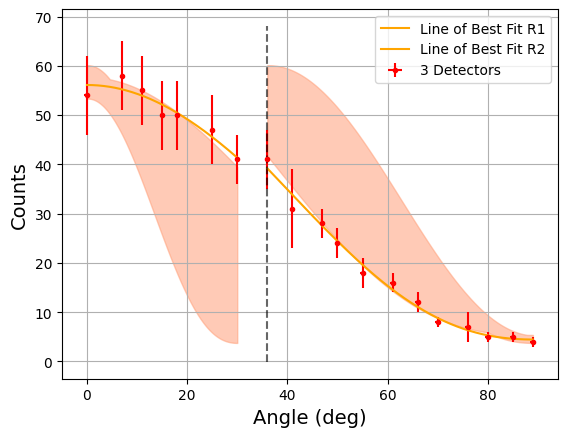

In [11]:
# Plot data and fit

plotRange1 = np.linspace(min(dlvals1), max(dlvals1), 1000)
plotRange2 = np.linspace(min(dlvals2), max(dlvals2), 1000)

print(rf"A: {params1[0]} +/- {np.sqrt(paramerr1[0][0])}")
print(rf"n: {params1[1]} +/- {np.sqrt(paramerr1[1][1])}")
print(rf"B: {params1[2]} +/- {np.sqrt(paramerr1[2][2])}")

print(rf"A: {params2[0]} +/- {np.sqrt(paramerr2[0][0])}")
print(rf"n: {params2[1]} +/- {np.sqrt(paramerr2[1][1])}")
print(rf"B: {params2[2]} +/- {np.sqrt(paramerr2[2][2])}")

plt.errorbar(anglesListVals, tripleListVals, xerr = xErr, yerr = tripleListErrs, fmt = '.',color = 'red' , label = "3 Detectors")
plt.plot(plotRange1, fitting_funct_1(plotRange1, [params1[0], params1[1], params1[2]]), color = 'orange', alpha = 1, label = 'Line of Best Fit R1')
plt.plot(plotRange2, fitting_funct_2(plotRange2, [params2[0], params2[1], params2[2]]), color = 'orange', alpha = 1, label = 'Line of Best Fit R2')
plt.vlines(anglesListVals[separator], ymin=plt.ylim()[0], ymax= plt.ylim()[1], color = 'black',linestyles= 'dashed', alpha = 0.6) 

p0rnge = np.linspace(params1[0]-np.sqrt(paramerr1[0][0]), params1[0]+np.sqrt(paramerr1[0][0]), 20)
p1rnge = np.linspace(params1[1]-np.sqrt(paramerr1[1][1]), params1[1]+np.sqrt(paramerr1[1][1]), 20)
p2rnge = np.linspace(params1[2]-np.sqrt(paramerr1[2][2]), params1[2]+np.sqrt(paramerr1[2][2]), 20)

xrange1 = np.linspace(min(dlvals1), max(dlvals1), 1000)
xrange2 = np.linspace(min(dlvals2), max(dlvals2), 1000)

ymin1 = fitting_funct_1(xrange1,[p0rnge[0], p1rnge[0], p2rnge[0]])
ymax1 = fitting_funct_1(xrange1,[p0rnge[0], p1rnge[0], p2rnge[0]])

for p0 in p0rnge:
    for p1 in p1rnge:
        for p2 in p2rnge:
            buf = fitting_funct_1(xrange1, [p0,p1,p2])
            ymin1 = np.minimum(ymin, buf)
            ymax1 = np.maximum(ymax, buf)

plt.fill_between(xrange1,ymin1,ymax1,color = 'lightsalmon', alpha = 0.55)

p0rnge = np.linspace(params2[0]-np.sqrt(paramerr2[0][0]), params2[0]+np.sqrt(paramerr2[0][0]), 20)
p1rnge = np.linspace(params2[1]-np.sqrt(paramerr2[1][1]), params2[1]+np.sqrt(paramerr2[1][1]), 20)
p2rnge = np.linspace(params2[2]-np.sqrt(paramerr2[2][2]), params2[2]+np.sqrt(paramerr2[2][2]), 20)

ymin2 = fitting_funct_2(xrange,[p0rnge[0], p1rnge[0], p2rnge[0]])
ymax2 = fitting_funct_2(xrange,[p0rnge[0], p1rnge[0], p2rnge[0]])

for p0 in p0rnge:
    for p1 in p1rnge:
        for p2 in p2rnge:
            buf = fitting_funct_2(xrange2, [p0,p1,p2])
            ymin2 = np.minimum(ymin, buf)
            ymax2 = np.maximum(ymax, buf)

plt.fill_between(xrange2,ymin2,ymax2,color = 'lightsalmon', alpha = 0.55)

plt.xlabel("Angle (deg)", fontdict = {'size' : 14})
plt.ylabel("Counts" , fontdict = {'size' : 14})
plt.grid()
plt.legend()
plt.show()